In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
import os

os.listdir("../data/processed")

['alpha_beta.csv',
 'cagr_comparison.csv',
 'clean_01_fund_master.csv',
 'clean_03_aum_by_fund_house.csv',
 'clean_04_monthly_sip_inflows.csv',
 'clean_05_category_inflows.csv',
 'clean_06_industry_folio_count.csv',
 'clean_09_portfolio_holdings.csv',
 'clean_10_benchmark_indices.csv',
 'clean_nav_history.csv',
 'clean_scheme_performance.csv',
 'clean_transactions.csv',
 'daily_returns.csv',
 'fund_scorecard.csv',
 'maximum_drawdown.csv',
 'sharpe_ratio.csv',
 'sortino_ratio.csv',
 'tracking_error.csv']

In [ ]:
import pandas as pd


fund_master = pd.read_csv(
    "../data/processed/clean_01_fund_master.csv"
)


nav = pd.read_csv(
    "../data/processed/clean_nav_history.csv",
    parse_dates=["date"]
)


transactions = pd.read_csv(
    "../data/processed/clean_transactions.csv",
    parse_dates=["transaction_date"]
)


performance = pd.read_csv(
    "../data/processed/clean_scheme_performance.csv"
)

In [ ]:

nav = nav.sort_values(["amfi_code", "date"])


nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()


nav = nav.dropna(subset=["daily_return"])

nav.head()

,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


In [ ]:
risk_report = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"]

   
    var95 = returns.quantile(0.05)

    cvar95 = returns[returns <= var95].mean()

    risk_report.append({
        "amfi_code": code,
        "VaR_95": round(var95, 6),
        "CVaR_95": round(cvar95, 6)
    })

risk_report = pd.DataFrame(risk_report)

risk_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [10]:
risk_report = risk_report.merge(
    performance[
        ["amfi_code", "scheme_name", "risk_grade"]
    ],
    on="amfi_code",
    how="left"
)

risk_report.head()

,amfi_code,VaR_95,CVaR_95,scheme_name,risk_grade
0,100016,-0.014364,-0.018060,HDFC Top 100 Fund - Regular Plan - Growth,Moderate
1,100025,-0.003793,-0.004994,HDFC Short Term Debt Fund - Regular - Growth,Low
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,High
3,101206,-0.013282,-0.017439,ABSL Frontline Equity Fund - Regular - Growth,Moderate
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth,Very High


In [11]:
highest_risk = risk_report.sort_values(
    by="VaR_95"
)

highest_risk.head(10)

,amfi_code,VaR_95,CVaR_95,scheme_name,risk_grade
22,119599,-0.026859,-0.032384,SBI Small Cap Fund - Direct Plan - Growth,Very High
17,119095,-0.026188,-0.031667,Axis Small Cap Fund - Regular - Growth,Very High
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth,Very High
11,118634,-0.025438,-0.032304,Nippon India Small Cap Fund - Regular - Growth,Very High
21,119598,-0.024507,-0.030595,SBI Small Cap Fund - Regular Plan - Growth,Very High
39,149324,-0.023483,-0.031036,DSP Small Cap Fund - Regular - Growth,Very High
7,102886,-0.019220,-0.023251,UTI Mid Cap Fund - Regular - Growth,High
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,High
25,120505,-0.018892,-0.024342,ICICI Pru Midcap Fund - Regular - Growth,High
16,119094,-0.018480,-0.024260,Axis Midcap Fund - Regular - Growth,High


In [12]:
risk_report.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

print(" var_cvar_report.csv saved successfully!")

 var_cvar_report.csv saved successfully!


In [13]:
print("Total Funds:", len(risk_report))
print(risk_report.describe())

Total Funds: 40
           amfi_code     VaR_95    CVaR_95
count      40.000000  40.000000  40.000000
mean   120247.000000  -0.014711  -0.018580
std     14534.998667   0.006821   0.008476
min    100016.000000  -0.026859  -0.032459
25%    118632.750000  -0.018394  -0.023133
50%    119551.500000  -0.014376  -0.018185
75%    120842.250000  -0.013247  -0.016572
max    149324.000000  -0.000222  -0.000373


In [14]:
import numpy as np


risk_free_rate = 0.065

rolling_sharpe_list = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

   
    daily_rf = risk_free_rate / 252

 
    group["excess_return"] = group["daily_return"] - daily_rf

   
    rolling_mean = group["excess_return"].rolling(window=90).mean()

 
    rolling_std = group["daily_return"].rolling(window=90).std()

  
    group["rolling_sharpe"] = (
        rolling_mean / rolling_std
    ) * np.sqrt(252)

    rolling_sharpe_list.append(group)

rolling_sharpe = pd.concat(
    rolling_sharpe_list,
    ignore_index=True
)

rolling_sharpe.head()

,amfi_code,date,nav,daily_return,excess_return,rolling_sharpe
0,100016,2022-01-04,515.0971,-0.010306,-0.010564,NaN
1,100016,2022-01-05,521.7239,0.012865,0.012607,NaN
2,100016,2022-01-06,515.7880,-0.011377,-0.011635,NaN
3,100016,2022-01-07,515.1639,-0.001210,-0.001468,NaN
4,100016,2022-01-10,510.7136,-0.008639,-0.008897,NaN


In [15]:
top5_codes = performance.sort_values(
    by="sharpe_ratio",
    ascending=False
).head(5)["amfi_code"]

top5_codes

14    120507
23    120844
30    101208
9     100025
4     119120
Name: amfi_code, dtype: int64

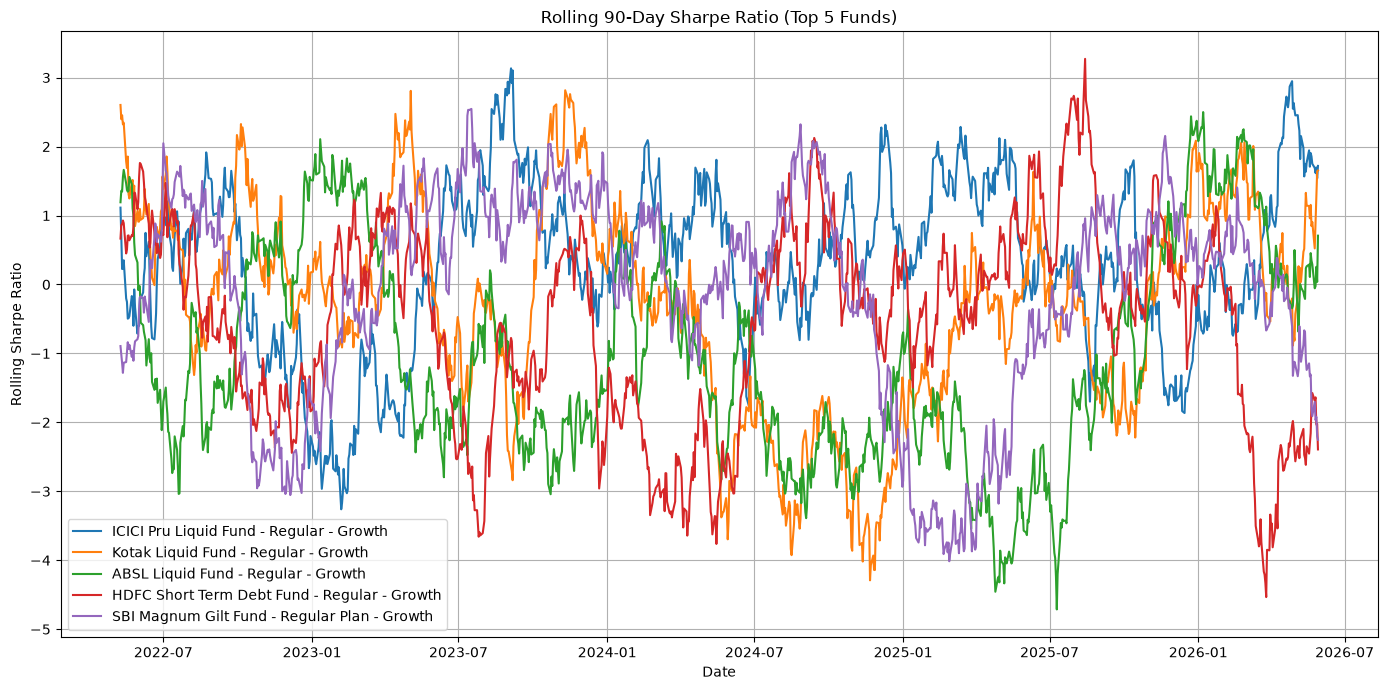

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

for code in top5_codes:

    temp = rolling_sharpe[
        rolling_sharpe["amfi_code"] == code
    ]

    scheme = performance.loc[
        performance["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=scheme
    )

plt.title("Rolling 90-Day Sharpe Ratio (Top 5 Funds)")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show()

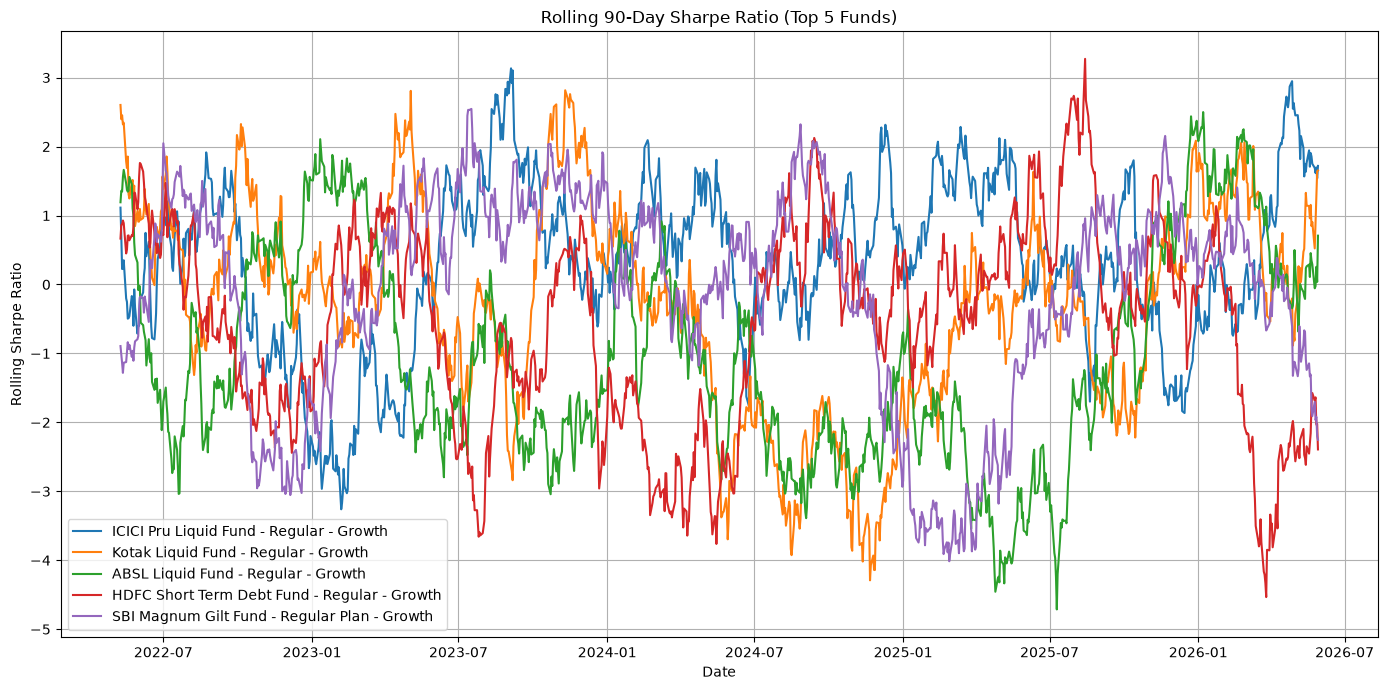

✅ rolling_sharpe_chart.png saved successfully!


In [17]:
plt.figure(figsize=(14,7))

for code in top5_codes:

    temp = rolling_sharpe[
        rolling_sharpe["amfi_code"] == code
    ]

    scheme = performance.loc[
        performance["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=scheme
    )

plt.title("Rolling 90-Day Sharpe Ratio (Top 5 Funds)")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300
)

plt.show()

print("✅ rolling_sharpe_chart.png saved successfully!")

In [18]:
rolling_sharpe.to_csv(
    "../data/processed/rolling_sharpe.csv",
    index=False
)


In [19]:
cohort = (
    transactions.groupby("investor_id")["transaction_date"]
    .min()
    .dt.year
    .reset_index()
)

cohort.columns = ["investor_id", "cohort_year"]

cohort.head()

,investor_id,cohort_year
0,INV000001,2024
1,INV000002,2024
2,INV000003,2024
3,INV000004,2024
4,INV000005,2024


In [20]:
transactions = transactions.merge(
    cohort,
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [21]:
cohort_summary = (
    transactions.groupby("cohort_year")
    .agg(
        Avg_SIP_Amount=("amount_inr", "mean"),
        Total_Investment=("amount_inr", "sum"),
        Total_Investors=("investor_id", "nunique")
    )
    .reset_index()
)

cohort_summary

,cohort_year,Avg_SIP_Amount,Total_Investment,Total_Investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [22]:
top_fund = (
    transactions.groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="transactions")
)

top_fund = (
    top_fund.sort_values(
        ["cohort_year", "transactions"],
        ascending=[True, False]
    )
    .groupby("cohort_year")
    .first()
    .reset_index()
)

top_fund.head()

,cohort_year,amfi_code,transactions
0,2024,148568,874
1,2025,119599,12


In [23]:
top_fund = top_fund.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

top_fund = top_fund[
    ["cohort_year", "scheme_name"]
]

top_fund

,cohort_year,scheme_name
0,2024,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,SBI Small Cap Fund - Direct Plan - Growth


In [24]:
cohort_report = cohort_summary.merge(
    top_fund,
    on="cohort_year"
)

cohort_report.rename(
    columns={
        "scheme_name": "Top_Fund_Preference"
    },
    inplace=True
)

cohort_report

,cohort_year,Avg_SIP_Amount,Total_Investment,Total_Investors,Top_Fund_Preference
0,2024,107422.541832,3491125187,4803,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,109158.577061,30455243,197,SBI Small Cap Fund - Direct Plan - Growth


In [25]:
cohort_report.to_csv(
    "../data/processed/investor_cohort_analysis.csv",
    index=False
)

print(" investor_cohort_analysis.csv saved successfully!")

 investor_cohort_analysis.csv saved successfully!


In [38]:
print(transactions["transaction_type"].value_counts())
print(transactions["transaction_type"].unique())

transaction_type
Sip           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64
<StringArray>
['Sip', 'Redemption', 'Lumpsum']
Length: 3, dtype: str


In [39]:
transactions["transaction_type"] = (
    transactions["transaction_type"]
    .astype(str)
    .str.strip()
    .str.lower()
)

In [40]:
transactions["transaction_type"].value_counts()

transaction_type
sip           19716
lumpsum        8095
redemption     4967
Name: count, dtype: int64

In [41]:
sip = transactions[
    transactions["transaction_type"] == "sip"
].copy()

print(sip.shape)
sip.head()

(19716, 14)


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,sip,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,sip,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [42]:
sip = sip.sort_values(["investor_id", "transaction_date"])

sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

sip_count = (
    sip.groupby("investor_id")
       .size()
       .reset_index(name="sip_count")
)

print(sip_count["sip_count"].max())

12


In [43]:
print(transactions["transaction_type"].unique())

<StringArray>
['sip', 'redemption', 'lumpsum']
Length: 3, dtype: str


In [44]:
sip = transactions[
    transactions["transaction_type"] == "sip"
].copy()

print("SIP Transactions:", sip.shape)

SIP Transactions: (19716, 14)


In [45]:
sip_count = (
    sip.groupby("investor_id")
       .size()
       .reset_index(name="sip_count")
)

print(sip_count.head())
print("Maximum SIP transactions by one investor:", sip_count["sip_count"].max())

  investor_id  sip_count
0   INV000001          2
1   INV000002          3
2   INV000003          2
3   INV000004          6
4   INV000005          3
Maximum SIP transactions by one investor: 12


In [46]:
print(sip_count["sip_count"].value_counts().sort_index())

sip_count
1     728
2     687
3     660
4     670
5     655
6     528
7     412
8     241
9     122
10     49
11      9
12      1
Name: count, dtype: int64


In [47]:
print(sip_count["sip_count"].value_counts().sort_index())

sip_count
1     728
2     687
3     660
4     670
5     655
6     528
7     412
8     241
9     122
10     49
11      9
12      1
Name: count, dtype: int64


In [48]:
sip = transactions[
    transactions["transaction_type"] == "sip"
].copy()

In [49]:
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

In [50]:
sip_count = (
    sip.groupby("investor_id")
       .size()
       .reset_index(name="sip_count")
)

eligible = sip_count[
    sip_count["sip_count"] >= 6
]

print(eligible.shape)
eligible.head()

(1362, 2)


,investor_id,sip_count
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8


In [51]:
avg_gap = (
    sip.groupby("investor_id")["gap_days"]
       .mean()
       .reset_index(name="avg_gap_days")
)

avg_gap.head()

,investor_id,avg_gap_days
0,INV000001,76.0
1,INV000002,207.0
2,INV000003,238.0
3,INV000004,85.4
4,INV000005,14.0


In [52]:
sip_continuity = eligible.merge(
    avg_gap,
    on="investor_id"
)

sip_continuity.head()

,investor_id,sip_count,avg_gap_days
0,INV000004,6,85.400000
1,INV000008,6,70.400000
2,INV000010,6,64.800000
3,INV000011,7,40.166667
4,INV000012,8,57.000000


In [53]:
import numpy as np

sip_continuity["status"] = np.where(
    sip_continuity["avg_gap_days"] > 35,
    "At Risk",
    "Active"
)

sip_continuity.head()

,investor_id,sip_count,avg_gap_days,status
0,INV000004,6,85.400000,At Risk
1,INV000008,6,70.400000,At Risk
2,INV000010,6,64.800000,At Risk
3,INV000011,7,40.166667,At Risk
4,INV000012,8,57.000000,At Risk


In [54]:
print(sip_continuity["status"].value_counts())

status
At Risk    1332
Active       30
Name: count, dtype: int64


In [55]:
sip_continuity.to_csv(
    "../data/processed/sip_continuity_report.csv",
    index=False
)



In [57]:
risk = input(
    "Enter Risk Appetite (Low / Moderate / Moderately High / High / Very High): "
).strip()

recommendation = performance[
    performance["risk_grade"].str.lower() == risk.lower()
]

recommendation = recommendation.sort_values(
    by="sharpe_ratio",
    ascending=False
)

recommendation = recommendation[
    [
        "scheme_name",
        "fund_house",
        "category",
        "risk_grade",
        "sharpe_ratio",
        "return_3yr_pct"
    ]
].head(3)

if recommendation.empty:
    print("No funds found for the selected risk appetite.")
else:
    print("\nTop 3 Recommended Funds:\n")
    print(recommendation)

No funds found for the selected risk appetite.


In [58]:
recommendation.to_csv(
    "../data/processed/fund_recommendations.csv",
    index=False
)


In [59]:
portfolio = pd.read_csv("../data/processed/clean_09_portfolio_holdings.csv")

print(portfolio.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [60]:
portfolio = pd.read_csv(
    "../data/processed/clean_09_portfolio_holdings.csv"
)

portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [61]:

portfolio["weight"] = portfolio["weight_pct"] / 100


hhi = (
    portfolio.groupby("amfi_code")["weight"]
    .apply(lambda x: (x ** 2).sum())
    .reset_index(name="HHI")
)

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [62]:
hhi = hhi.merge(
    fund_master[
        ["amfi_code", "scheme_name", "category"]
    ],
    on="amfi_code",
    how="left"
)

hhi.head()

,amfi_code,HHI,scheme_name,category
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,Equity
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity


In [63]:
equity_hhi = hhi[
    hhi["category"].str.contains(
        "Equity",
        case=False,
        na=False
    )
]

equity_hhi.head()

,amfi_code,HHI,scheme_name,category
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,Equity
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity


In [64]:
equity_hhi = equity_hhi.sort_values(
    by="HHI",
    ascending=False
)

equity_hhi.head(10)

,amfi_code,HHI,scheme_name,category
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Equity
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,Equity
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Equity


In [65]:
print(
    equity_hhi[
        [
            "scheme_name",
            "HHI"
        ]
    ]
)

                                          scheme_name       HHI
11              Axis Bluechip Fund - Regular - Growth  0.206448
3              ABSL Small Cap Fund - Regular - Growth  0.200700
18          SBI Small Cap Fund - Direct Plan - Growth  0.174751
4          UTI Nifty 50 Index Fund - Regular - Growth  0.174709
7      Nippon India Large Cap Fund - Regular - Growth  0.168298
29  Mirae Asset Emerging Bluechip Fund - Regular -...  0.167930
21           ICICI Pru Midcap Fund - Regular - Growth  0.157570
22  ICICI Pru Value Discovery Fund - Regular - Growth  0.153794
27  HDFC Mid-Cap Opportunities Fund - Direct - Growth  0.152414
23             Kotak Bluechip Fund - Regular - Growth  0.149680
30      Mirae Asset Tax Saver Fund - Regular - Growth  0.149396
1   HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.147592
32                 DSP Midcap Fund - Regular - Growth  0.141621
19         ICICI Pru Bluechip Fund - Regular - Growth  0.140870
0           HDFC Top 100 Fund - Regular 

In [66]:
equity_hhi.to_csv(
    "../data/processed/hhi_concentration_report.csv",
    index=False
)

print("hhi_concentration_report.csv saved successfully!")

hhi_concentration_report.csv saved successfully!


In [67]:
print("Total Equity Funds :", len(equity_hhi))

print("\nTop 5 Most Concentrated Funds\n")

print(
    equity_hhi[
        [
            "scheme_name",
            "HHI"
        ]
    ].head()
)

Total Equity Funds : 34

Top 5 Most Concentrated Funds

                                       scheme_name       HHI
11           Axis Bluechip Fund - Regular - Growth  0.206448
3           ABSL Small Cap Fund - Regular - Growth  0.200700
18       SBI Small Cap Fund - Direct Plan - Growth  0.174751
4       UTI Nifty 50 Index Fund - Regular - Growth  0.174709
7   Nippon India Large Cap Fund - Regular - Growth  0.168298


# Advanced Analytics – Business Insights

---- Insight 1: Historical VaR & CVaR
The Historical Value at Risk (VaR) and Conditional Value at Risk (CVaR) analysis identified funds with the highest downside risk. Funds with larger negative VaR and CVaR values are more vulnerable during adverse market conditions and require careful monitoring by investors.

----- Insight 2: Rolling 90-Day Sharpe Ratio
The Rolling Sharpe Ratio analysis highlighted the consistency of risk-adjusted returns over time. Funds with consistently higher Sharpe Ratios demonstrated better performance by delivering superior returns for each unit of risk taken.

--- Insight 3: Investor Cohort Analysis
Investor cohort analysis showed that investment behavior varies across different cohorts. Recent investor cohorts contributed higher investment amounts, while certain funds emerged as the most preferred choices among long-term investors.

--- Insight 4: SIP Continuity Analysis
The SIP continuity analysis identified investors with irregular investment patterns. Investors having an average SIP gap greater than 35 days were classified as "At Risk", enabling fund managers to target retention campaigns effectively.

---- Insight 5: Portfolio Concentration (HHI)
The Herfindahl-Hirschman Index (HHI) measured portfolio concentration across equity funds. Funds with higher HHI values indicated concentrated holdings, whereas lower HHI values represented better diversification and reduced concentration risk.